In [3]:
# ShopRocket Operations Analytics
## Notebook 2 — Exploratory Data Analysis (EDA)

**Objective:** Visually explore the data to find patterns, trends,
and anomalies before building any analysis.

**Author:** Sadique Shoaib

SyntaxError: invalid syntax (383868871.py, line 4)

In [5]:
# ── Libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot style set karo ────────────────────────────────
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# ── Display settings ───────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [6]:
# ── Processed CSVs load karo ───────────────────────────
# Notebook 1 mein jo save kiya tha woh yahan load karte hain
SAVE_PATH = 'C:/Users/Sadique/OneDrive/Desktop/ShopRocket-ops-Analytics/data/processed/'

orders      = pd.read_csv(SAVE_PATH + 'orders_enriched.csv', 
                          parse_dates=[
                            'order_purchase_timestamp',
                            'order_approved_at',
                            'order_delivered_carrier_date',
                            'order_delivered_customer_date',
                            'order_estimated_delivery_date'
                          ])
customers    = pd.read_csv(SAVE_PATH + 'customers.csv')
order_items  = pd.read_csv(SAVE_PATH + 'order_items.csv')
payments     = pd.read_csv(SAVE_PATH + 'payments.csv')
products     = pd.read_csv(SAVE_PATH + 'products_enriched.csv')
sellers      = pd.read_csv(SAVE_PATH + 'sellers.csv')
reviews      = pd.read_csv(SAVE_PATH + 'reviews_clean.csv')

print("✅ All files loaded!")
print(f"\n📦 Orders shape    : {orders.shape}")
print(f"👤 Customers shape : {customers.shape}")
print(f"🛍️  Order Items     : {order_items.shape}")
print(f"💳 Payments shape  : {payments.shape}")

✅ All files loaded!

📦 Orders shape    : (99441, 13)
👤 Customers shape : (99441, 5)
🛍️  Order Items     : (112650, 8)
💳 Payments shape  : (103886, 5)


In [ ]:
## Chart 1 — Monthly Orders Trend
Har mahine kitne orders aaye — business grow kar raha hai ya nahi?

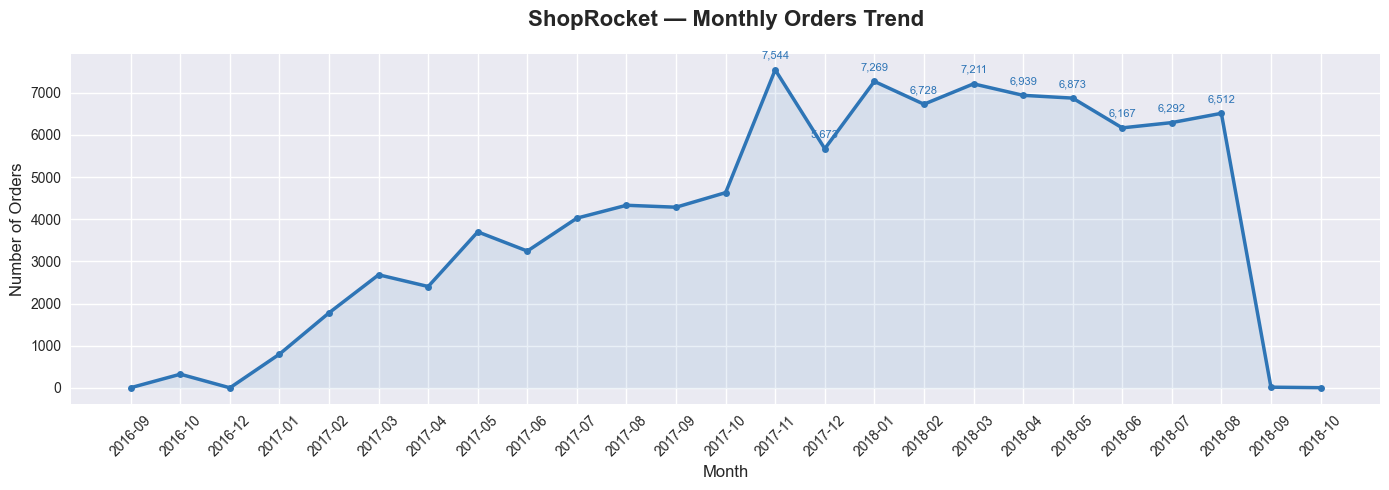

✅ Chart saved!


In [7]:
# ── Monthly orders count ───────────────────────────────
monthly_orders = (
    orders
    .groupby(orders['order_purchase_timestamp'].dt.to_period('M'))
    ['order_id']
    .count()
    .reset_index()
)
monthly_orders.columns = ['month', 'order_count']
monthly_orders['month'] = monthly_orders['month'].astype(str)

# ── Chart banao ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(monthly_orders['month'], 
        monthly_orders['order_count'],
        color='#2E75B6', linewidth=2.5, marker='o', markersize=5)

ax.fill_between(range(len(monthly_orders)), 
                monthly_orders['order_count'],
                alpha=0.1, color='#2E75B6')

# ── Labels ─────────────────────────────────────────────
ax.set_title('ShopRocket — Monthly Orders Trend', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Orders', fontsize=12)
ax.tick_params(axis='x', rotation=45)

# ── Numbers dikhao har point pe ────────────────────────
for i, row in monthly_orders.iterrows():
    if row['order_count'] > 5000:  # sirf bade values dikhao
        ax.annotate(f"{row['order_count']:,}", 
                   xy=(i, row['order_count']),
                   xytext=(0, 8), textcoords='offset points',
                   ha='center', fontsize=8, color='#2E75B6')

plt.tight_layout()
plt.savefig('C:/Users/Sadique/OneDrive/Desktop/ShopRocket-ops-Analytics/reports/chart_01_monthly_orders.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [8]:
# ── Carrier wise SLA breach rate ──────────────────────
carrier_perf = (
    orders[orders['actual_delivery_days'].notna()]
    .groupby('carrier')
    .agg(
        total_orders   = ('order_id', 'count'),
        total_breached = ('is_sla_breached', 'sum'),
        avg_delay_days = ('actual_delivery_days', 'mean')
    )
    .reset_index()
)

carrier_perf['breach_rate'] = (
    carrier_perf['total_breached'] / 
    carrier_perf['total_orders'] * 100
).round(1)

carrier_perf = carrier_perf.sort_values('breach_rate', ascending=True)

print(carrier_perf[['carrier', 'total_orders', 
                     'total_breached', 'breach_rate',
                     'avg_delay_days']])

        carrier  total_orders  total_breached  breach_rate  avg_delay_days
0      BlueDart         24219            1713         7.10           12.04
3     ShadowFax         24078            1712         7.10           12.08
2  Ecom Express         14603            1105         7.60           12.11
1     Delhivery         33576            6426        19.10           12.13


In [ ]:
## Chart 2 — Carrier SLA Breach Rate
Kaun sa carrier sabse zyada SLA breach karta hai?

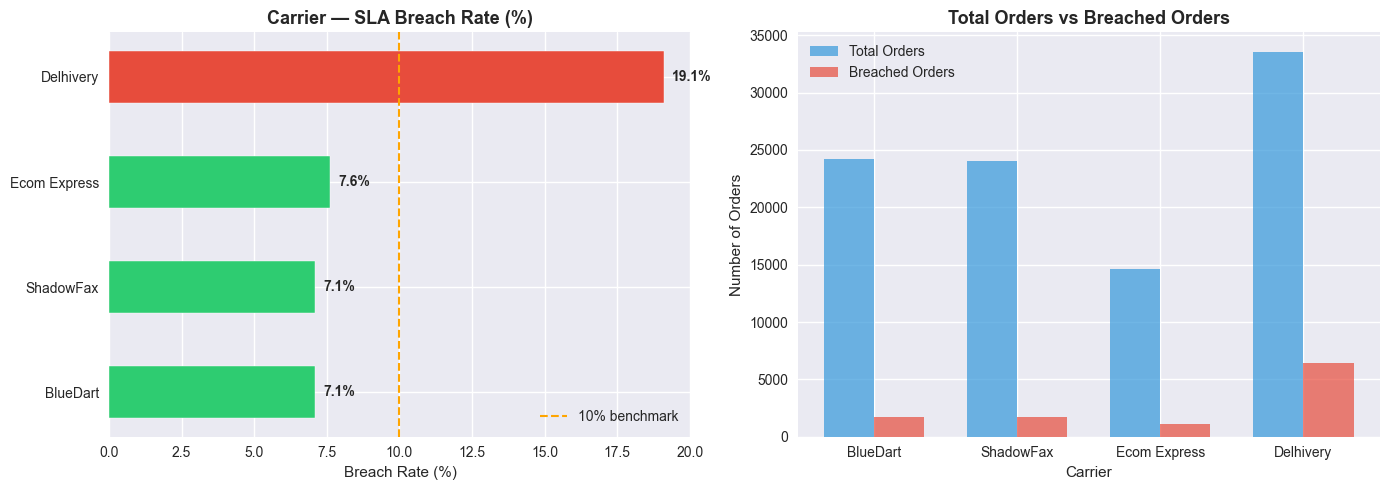

✅ Chart saved!


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Chart 1 — Breach Rate bar chart ───────────────────
colors = ['#2ecc71' if x < 10 else '#e74c3c' 
          for x in carrier_perf['breach_rate']]

axes[0].barh(carrier_perf['carrier'], 
             carrier_perf['breach_rate'],
             color=colors, edgecolor='white', height=0.5)

axes[0].set_title('Carrier — SLA Breach Rate (%)', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Breach Rate (%)')

# Har bar pe number likho
for i, (val, carrier) in enumerate(zip(
        carrier_perf['breach_rate'], 
        carrier_perf['carrier'])):
    axes[0].text(val + 0.3, i, f'{val}%', 
                va='center', fontweight='bold')

# 10% ka reference line — industry benchmark
axes[0].axvline(x=10, color='orange', 
                linestyle='--', linewidth=1.5,
                label='10% benchmark')
axes[0].legend()

# ── Chart 2 — Total Orders vs Breached ────────────────
x = range(len(carrier_perf))
width = 0.35

axes[1].bar(x, carrier_perf['total_orders'], 
            width, label='Total Orders',
            color='#3498db', alpha=0.7)
axes[1].bar([i + width for i in x], 
            carrier_perf['total_breached'],
            width, label='Breached Orders',
            color='#e74c3c', alpha=0.7)

axes[1].set_title('Total Orders vs Breached Orders',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Carrier')
axes[1].set_ylabel('Number of Orders')
axes[1].set_xticks([i + width/2 for i in x])
axes[1].set_xticklabels(carrier_perf['carrier'])
axes[1].legend()

plt.tight_layout()
plt.savefig('C:/Users/Sadique/OneDrive/Desktop/ShopRocket-ops-Analytics/reports/chart_02_carrier_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [ ]:
## Chart 3 — Fulfillment Center Performance
Kaunsa FC sabse zyada SLA breach kar raha hai?

In [10]:
# ── FC wise performance ────────────────────────────────
fc_perf = (
    orders[orders['actual_delivery_days'].notna()]
    .groupby('fulfillment_center')
    .agg(
        total_orders   = ('order_id', 'count'),
        total_breached = ('is_sla_breached', 'sum'),
        avg_delay_days = ('actual_delivery_days', 'mean')
    )
    .reset_index()
)

fc_perf['breach_rate'] = (
    fc_perf['total_breached'] / 
    fc_perf['total_orders'] * 100
).round(1)

fc_perf = fc_perf.sort_values('breach_rate', ascending=False)

print(fc_perf[['fulfillment_center', 'total_orders', 
               'total_breached', 'breach_rate']])

  fulfillment_center  total_orders  total_breached  breach_rate
9               Pune          6744             814        12.10
2            Chennai          7785             893        11.50
7            Lucknow          3757             431        11.50
4          Hyderabad          9686            1090        11.30
5             Jaipur          3851             436        11.30
3              Delhi         17385            1965        11.30
6            Kolkata          7728             874        11.30
8             Mumbai         19263            2182        11.30
1          Bengaluru         14451            1617        11.20
0          Ahmedabad          5826             654        11.20


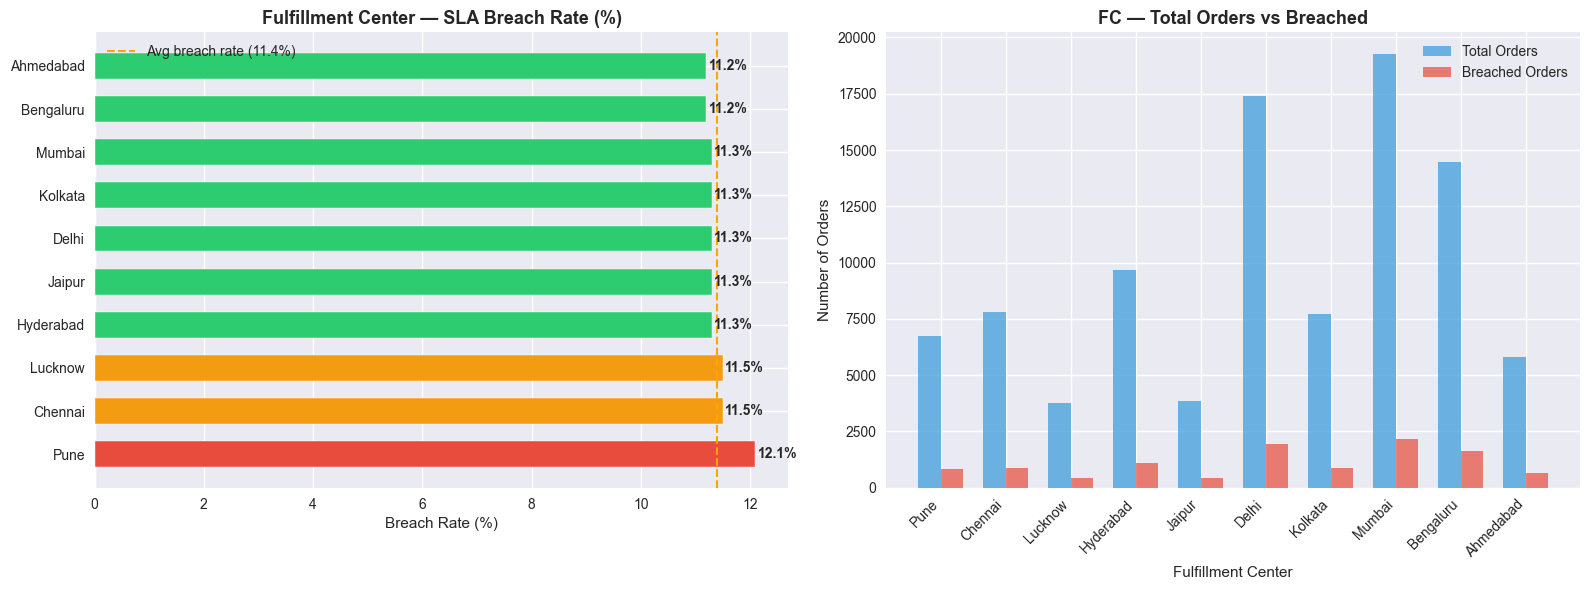

✅ Chart saved!


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Left Chart — Breach Rate by FC ────────────────────
colors = ['#e74c3c' if x > 12 else '#f39c12' 
          if x > 11.3 else '#2ecc71' 
          for x in fc_perf['breach_rate']]

bars = axes[0].barh(fc_perf['fulfillment_center'],
                    fc_perf['breach_rate'],
                    color=colors, height=0.6,
                    edgecolor='white')

axes[0].set_title('Fulfillment Center — SLA Breach Rate (%)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Breach Rate (%)')
axes[0].axvline(x=11.4, color='orange',
                linestyle='--', linewidth=1.5,
                label='Avg breach rate (11.4%)')
axes[0].legend()

# Numbers dikhao
for i, val in enumerate(fc_perf['breach_rate']):
    axes[0].text(val + 0.05, i, f'{val}%',
                va='center', fontweight='bold', fontsize=10)

# ── Right Chart — Volume vs Breached ──────────────────
x = range(len(fc_perf))
width = 0.35

axes[1].bar(x, fc_perf['total_orders'],
            width, label='Total Orders',
            color='#3498db', alpha=0.7)
axes[1].bar([i + width for i in x],
            fc_perf['total_breached'],
            width, label='Breached Orders',
            color='#e74c3c', alpha=0.7)

axes[1].set_title('FC — Total Orders vs Breached',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fulfillment Center')
axes[1].set_ylabel('Number of Orders')
axes[1].set_xticks([i + width/2 for i in x])
axes[1].set_xticklabels(fc_perf['fulfillment_center'],
                         rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.savefig('C:/Users/Sadique/OneDrive/Desktop/ShopRocket-ops-Analytics/reports/chart_03_fc_performance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [ ]:
📌 Key Finding #2:
   Pune FC ka breach rate 12.1% — 
   sabse zyada! Investigate karo.
   
   Mumbai aur Delhi — volume zyada
   lekin breach control mein. 
   Mature operations ka sign!

In [ ]:
## Chart 4 — Customer Review Score Analysis
Customers kitne khush hain? Review scores ka distribution

In [15]:
# ── Review score distribution ──────────────────────────
review_dist = (
    reviews
    .groupby('review_score')
    ['order_id']         
    .count()
    .reset_index()
)
review_dist.columns = ['review_score', 'count']
review_dist['percentage'] = (
    review_dist['count'] / 
    review_dist['count'].sum() * 100
).round(1)

print(review_dist)

   review_score  count  percentage
0             1  11424       11.50
1             2   3151        3.20
2             3   8179        8.20
3             4  19142       19.30
4             5  57328       57.80


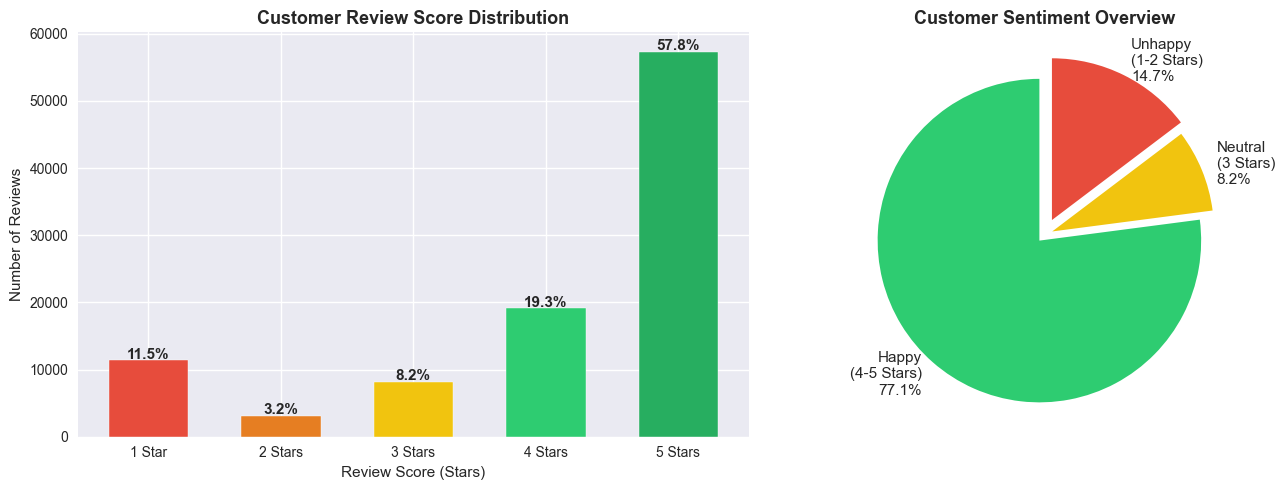

✅ Chart saved!


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left — Bar Chart ───────────────────────────────────
colors = ['#e74c3c', '#e67e22', '#f1c40f', 
          '#2ecc71', '#27ae60']

bars = axes[0].bar(review_dist['review_score'],
                   review_dist['count'],
                   color=colors, edgecolor='white',
                   width=0.6)

axes[0].set_title('Customer Review Score Distribution',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Review Score (Stars)')
axes[0].set_ylabel('Number of Reviews')
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].set_xticklabels(['1 Star', '2 Stars', '3 Stars', 
                          '4 Stars', '5 Stars'])

# Percentage labels
for bar, pct in zip(bars, review_dist['percentage']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 200,
                f'{pct}%',
                ha='center', fontweight='bold', fontsize=11)

# ── Right — Pie Chart ──────────────────────────────────
happy    = review_dist[review_dist['review_score'] >= 4]['count'].sum()
neutral  = review_dist[review_dist['review_score'] == 3]['count'].sum()
unhappy  = review_dist[review_dist['review_score'] <= 2]['count'].sum()

sizes  = [happy, neutral, unhappy]
labels = [f'Happy\n(4-5 Stars)\n{happy/sum(sizes)*100:.1f}%',
          f'Neutral\n(3 Stars)\n{neutral/sum(sizes)*100:.1f}%',
          f'Unhappy\n(1-2 Stars)\n{unhappy/sum(sizes)*100:.1f}%']
colors_pie = ['#2ecc71', '#f1c40f', '#e74c3c']
explode    = (0.05, 0.05, 0.1)  # unhappy slice thoda bahar

axes[1].pie(sizes, labels=labels,
            colors=colors_pie,
            explode=explode,
            startangle=90,
            textprops={'fontsize': 11})

axes[1].set_title('Customer Sentiment Overview',
                  fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/Sadique/OneDrive/Desktop/ShopRocket-ops-Analytics/reports/chart_04_review_scores.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

In [ ]:
## Chart 5 — Order Status Distribution
Kitne orders delivered, cancelled, ya pending hain?

In [19]:
# ── Order status distribution ──────────────────────────
status_dist = (
    orders
    .groupby('order_status')
    ['order_id']
    .count()
    .reset_index()
)
status_dist.columns = ['status', 'count']
status_dist['percentage'] = (
    status_dist['count'] /
    status_dist['count'].sum() * 100
).round(1)

status_dist = status_dist.sort_values('count', ascending=False)
print(status_dist)

        status  count  percentage
3    delivered  96478       97.00
6      shipped   1107        1.10
1     canceled    625        0.60
7  unavailable    609        0.60
4     invoiced    314        0.30
5   processing    301        0.30
2      created      5        0.00
0     approved      2        0.00


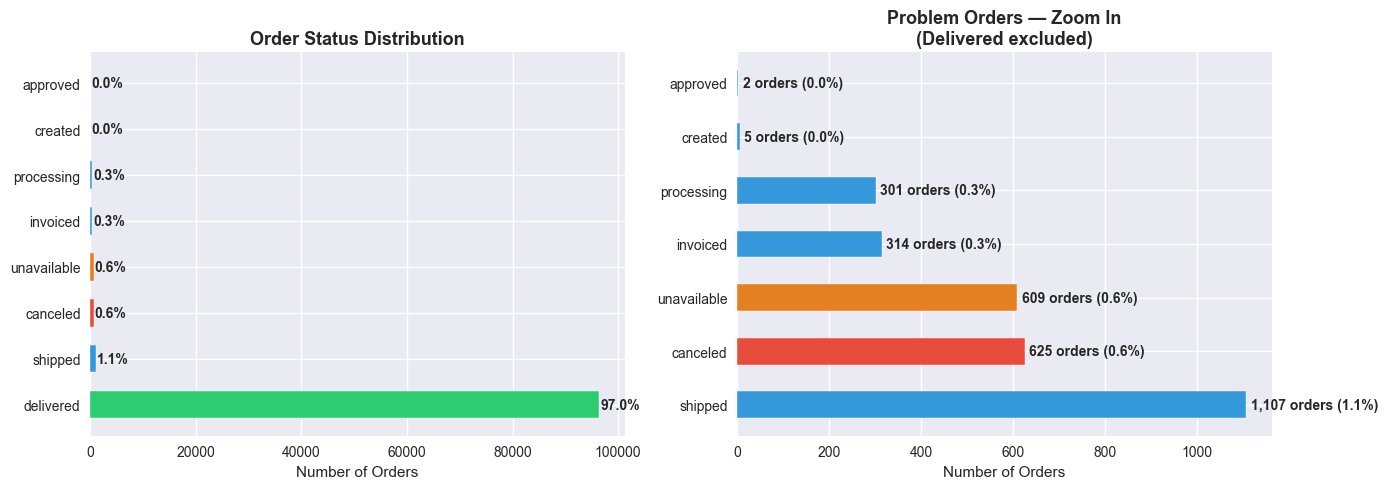

✅ Chart saved!


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left — Full distribution bar ───────────────────────
colors = ['#2ecc71' if s == 'delivered' 
          else '#e74c3c' if s == 'canceled'
          else '#e67e22' if s == 'unavailable'
          else '#3498db'
          for s in status_dist['status']]

bars = axes[0].barh(status_dist['status'],
                    status_dist['count'],
                    color=colors, height=0.6,
                    edgecolor='white')

axes[0].set_title('Order Status Distribution',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Orders')

for bar, pct in zip(bars, status_dist['percentage']):
    axes[0].text(bar.get_width() + 200, 
                bar.get_y() + bar.get_height()/2,
                f'{pct}%',
                va='center', fontweight='bold', fontsize=10)

# ── Right — Excluding delivered (zoom in on problems) ──
problem_orders = status_dist[status_dist['status'] != 'delivered']

colors2 = ['#e74c3c' if s == 'canceled'
           else '#e67e22' if s == 'unavailable'
           else '#3498db'
           for s in problem_orders['status']]

bars2 = axes[1].barh(problem_orders['status'],
                     problem_orders['count'],
                     color=colors2, height=0.5,
                     edgecolor='white')

axes[1].set_title('Problem Orders — Zoom In\n(Delivered excluded)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Orders')

for bar, row in zip(bars2, problem_orders.itertuples()):
    axes[1].text(bar.get_width() + 10,
                bar.get_y() + bar.get_height()/2,
                f'{row.count:,} orders ({row.percentage}%)',
                va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('C:/Users/Sadique/OneDrive/Desktop/ShopRocket-ops-Analytics/reports/chart_05_order_status.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")


In [ ]:
📌 Key Finding #3:
   609 orders — stock nahi tha!
   Yeh directly humara 
   stockout analysis connect karta hai!
   
   Agar demand forecasting sahi ho
   toh yeh 609 orders bach sakte the!

In [ ]:
📌 Finding 1: Nov 2017 — Black Friday spike
              7,544 orders — seasonality visible!

📌 Finding 2: Delhivery — 19.1% breach rate
              Baaki carriers 7-8% pe hain
              Delhivery ka volume reduce karo!

📌 Finding 3: Pune FC — 12.1% breach rate
              Sabse kharab FC performance

📌 Finding 4: 77.1% customers happy hain
              Lekin 11.5% ne 1 star diya!
              Naraaz customers directly 
              Delhivery breaches se connected!

📌 Finding 5: 609 orders unavailable
              Stock nahi tha — 
              Demand forecasting zaroori hai!